# Barcelona Traffic Accidents Analysis: 15-Year Temporal Patterns

This notebook explores historical patterns across four main time dimensions:
1. **Yearly Trends** (Long-term progression)
2. **Monthly Seasonality** (Seasonal fluctuations)
3. **Weekly Distribution** (Weekday commute vs. weekend leisure profiles)
4. **Hourly Profiles** (Daily rush hours vs. high-risk night intervals)
5. **Weekend Analysis** (Behavioral and Risk-Severity Cohort Study)

### Metrics Examined:
- **Volume Metrics**: Total Accidents, Total Injured, Total Deaths
- **Target Variable**: A binary indicator ($1$ or $0$) evaluating if an accident resulted in **severe injuries and/or fatalities**.
- **Impact Ratios**: The average number of injuries, deaths, and severe outcomes normalized **per accident**.

## Imports

In [1]:
import pandas as pd
import numpy as np
from random import randint
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')
import matplotlib as mpl
import python_files.functions_barcelona as fb
import python_files.paths_mapping as pm
import python_files.functions_plotting as fp
import matplotlib.colors as colors_pyplot


In [2]:
year= 2025
accidents = pd.read_csv(pm.FILES_PATH / f'accidents_weather{year}.csv',parse_dates=['datetime'])

if accidents.isnull().sum().sum() != 0:
    print(accidents.isnull().sum()[accidents.isnull().sum()>0].index)

accidents['target'] = ((accidents['num_deaths'] + accidents['num_severly_injured'])>0).astype(int)
int_columns =['hour', 'target','num_deaths','num_victims']
for col in int_columns:
    accidents[col] =accidents[col].astype(int)
accidents['weekday'] = accidents['weekday'].str[:3]
accidents['month'] = accidents['month'].str[:3]

# deaths_per_day = accidents.groupby(pd.Grouper(key='datetime', freq='D'))['num_deaths'].sum().sort_values(ascending=False)

# number_total_accidents = len(accidents)
# number_total_deaths = int(accidents['num_deaths'].sum())
# number_total_days = len(deaths_per_day)
# accidents['year'] = [int(x) for x in accidents['year']]

fp.creating_data_summary(accidents)

,Question_1,Answer_1,Answer_1.1,Question_2,Answer_2,Answer_2.1
1,Total accidents:,141338,,Month with the highest number of accidents:,Oct,12853
2,Total injuries:,165846,,Month with the highest number of injured:,Jul,15084
3,Total deaths:,354,,Month with the highest number of deaths:,Sep,40
4,Accidents per day:,24.19,,Weekday with the highest number of accidents:,Fri,24103
5,Deaths per accident(100):,0.25,,Weekday with the highest number of injured:,Fri,28171
6,Injured per accident:,1.17,,Weekday with the highest number of deaths:,Fri,68
7,Year with the highest number of accidents:,2017,10335,Hour with the highest number of accidents:,14,10391
8,Year with the highest number of injured:,2017,12182,Hour with the highest number of injured:,14,12712
9,Year with the highest number of deaths:,2010,39,Hour with the highest number of deaths:,17,68


## 1. **Yearly Trends**

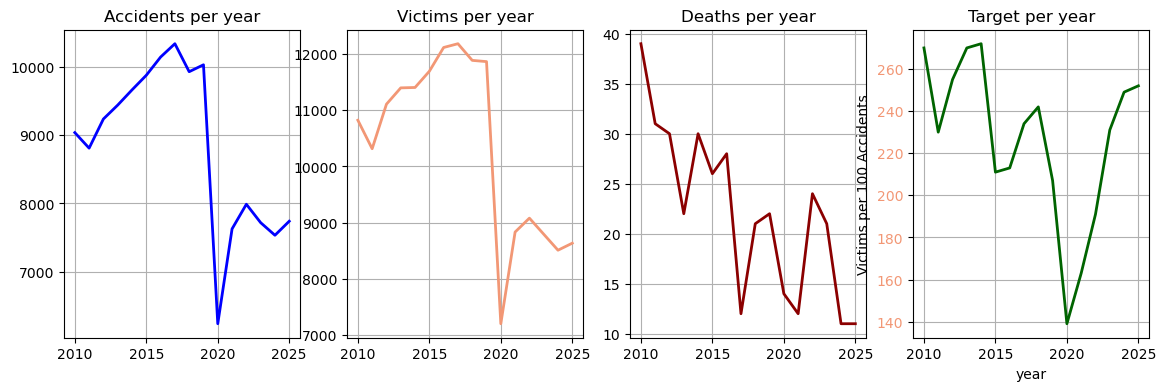

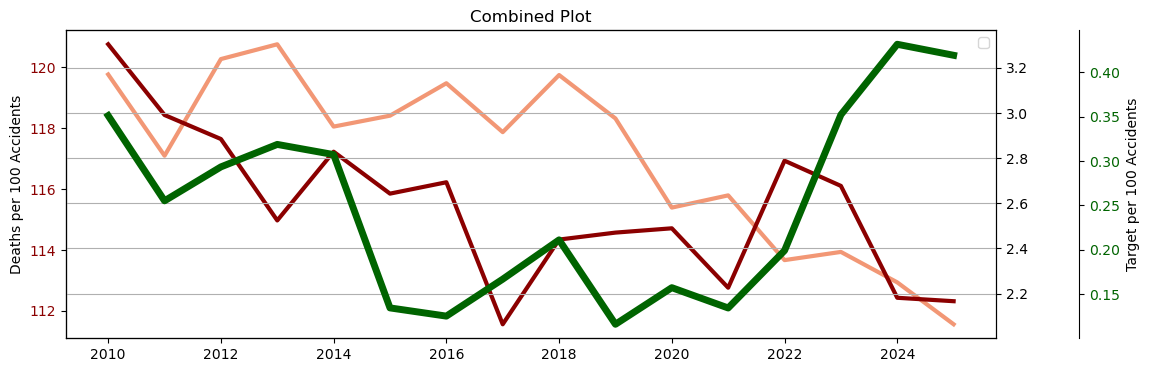

In [3]:
list_years =list(range(2010,year+1))
fp.viz_per_time_period(accidents,'year',list_years)

> While the number of accidents, injured, deaths and target when down during 2020 (pandemic effect), victims and accidents move together while deaths more erraticaly and target even more uncorrelated.

> It is interesting to see how injured per collision and deaths per collision in one hand and target per accident seem to move in an opposite directions after 2022. I will check its correlation.

In [4]:
yearly = accidents.groupby('year')[['num_incident','num_deaths', 'num_victims','target']].agg({'num_incident':'count',
                                                                                     'num_deaths':'sum',
                                                                                      'num_victims':'sum',
                                                                                     'target':'sum'})

yearly = yearly.div(yearly['num_incident'], axis=0).iloc[:,1:]*100
yearly.corr().loc['target',['num_deaths','num_victims']].to_frame()


,target
num_deaths,0.087561
num_victims,-0.348639


[Go back top](##Plotting:-TIME-BASED-FEATURES)


## 2. **Monthly Seasonality**

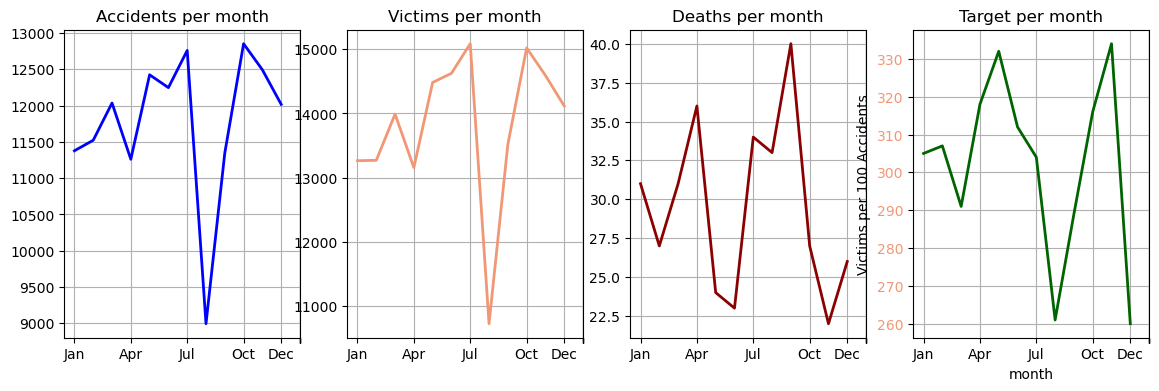

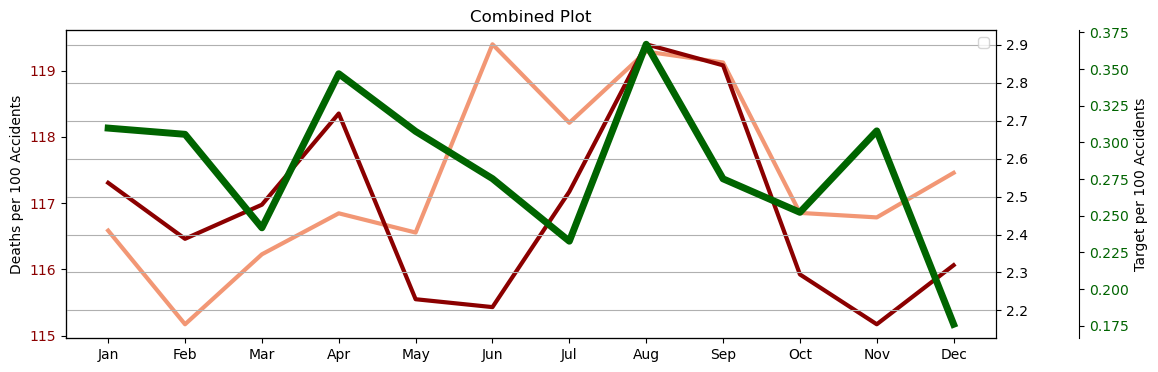

In [5]:
list_months =['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug',
'Sep', 'Oct', 'Nov','Dec']
fp.viz_per_time_period(accidents,'month',list_months)

#Next fix color for bars

> The months with a lowest number of accidents and injuries (April and August) are amongst the months with the highest number of deaths. August might be due to the holidays but April... Is it Easter?

> Look how the three ratios hit their peak in August. We also have June and November where they all seem to diverge.

## 3. **Weekly Distribution**

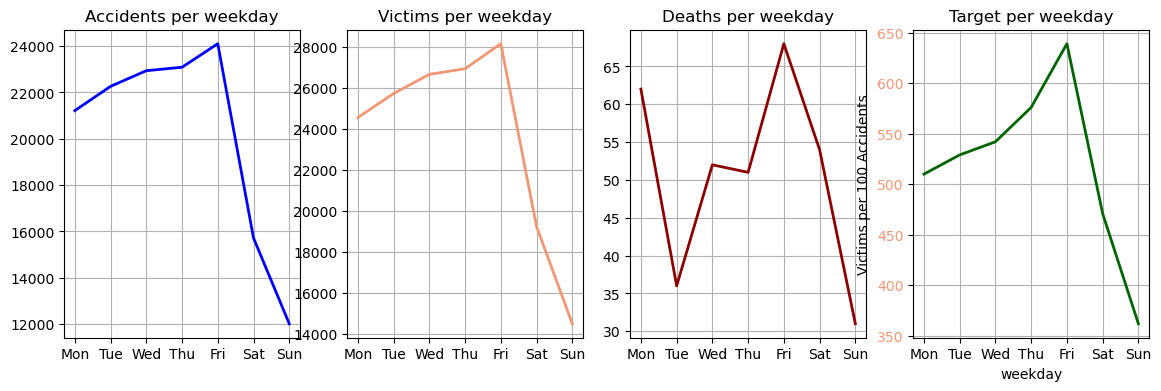

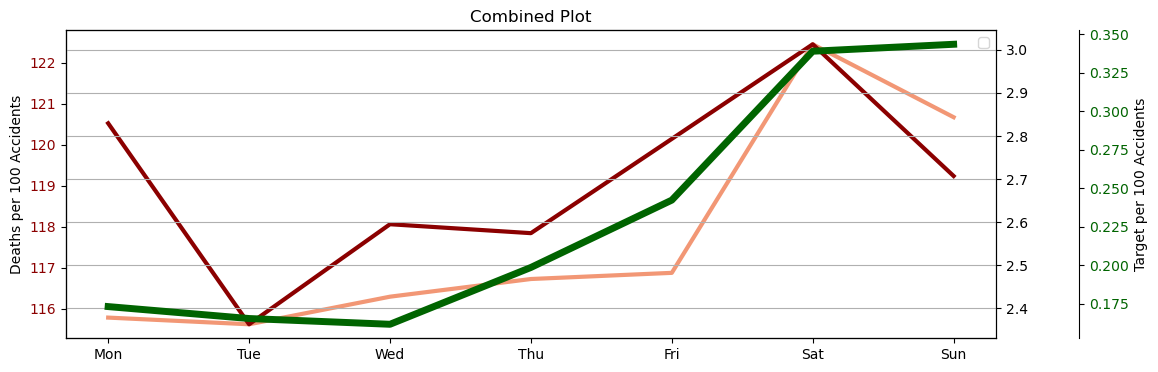

In [6]:
list_weekdays =['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fp.viz_per_time_period(accidents,'weekday',list_weekdays)

> Accidents, victims, deaths and target grow during the week to peak on Friday. After that, they have a steep decrease during the weekend.

> Ratios are different: they peak on Saturday (all of them; collecting data from Saturday morning--Friday night) and while deaths and accidents diminish going into Sunday, the raio for the target stay stable.

## 4. **Hourly Profiles**

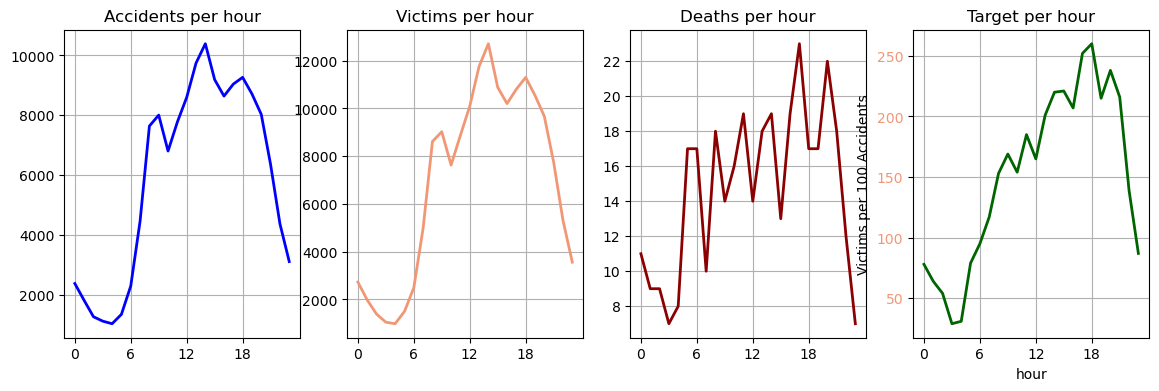

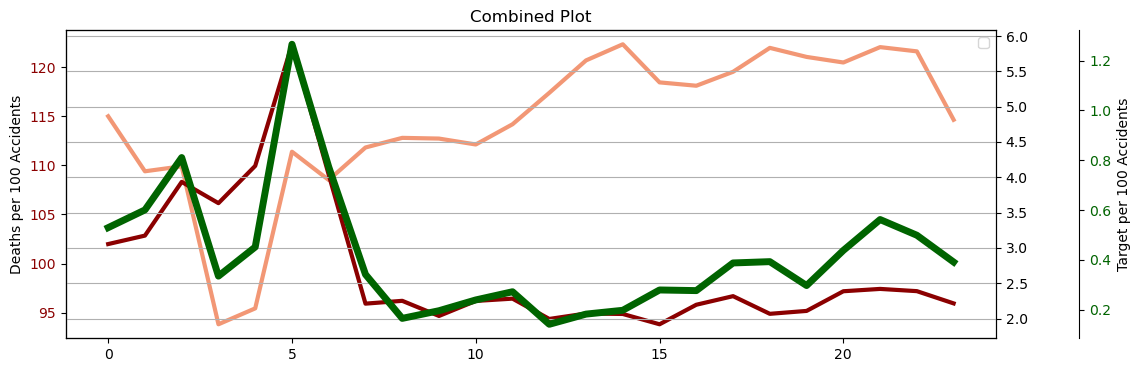

In [7]:
list_hours =list(range(0,24))
fp.viz_per_time_period(accidents,'hour',list_hours)

> As usual, accidents and victims move together while deaths and target have a different peak at a later hour.

> Ratios are different: they peak around 5 AM, all of them. From then on, although the number of victims keeps stable and even increasing, the other two ratios stabilize at a lower level.

## 5.1 **Weekend Analysis**.

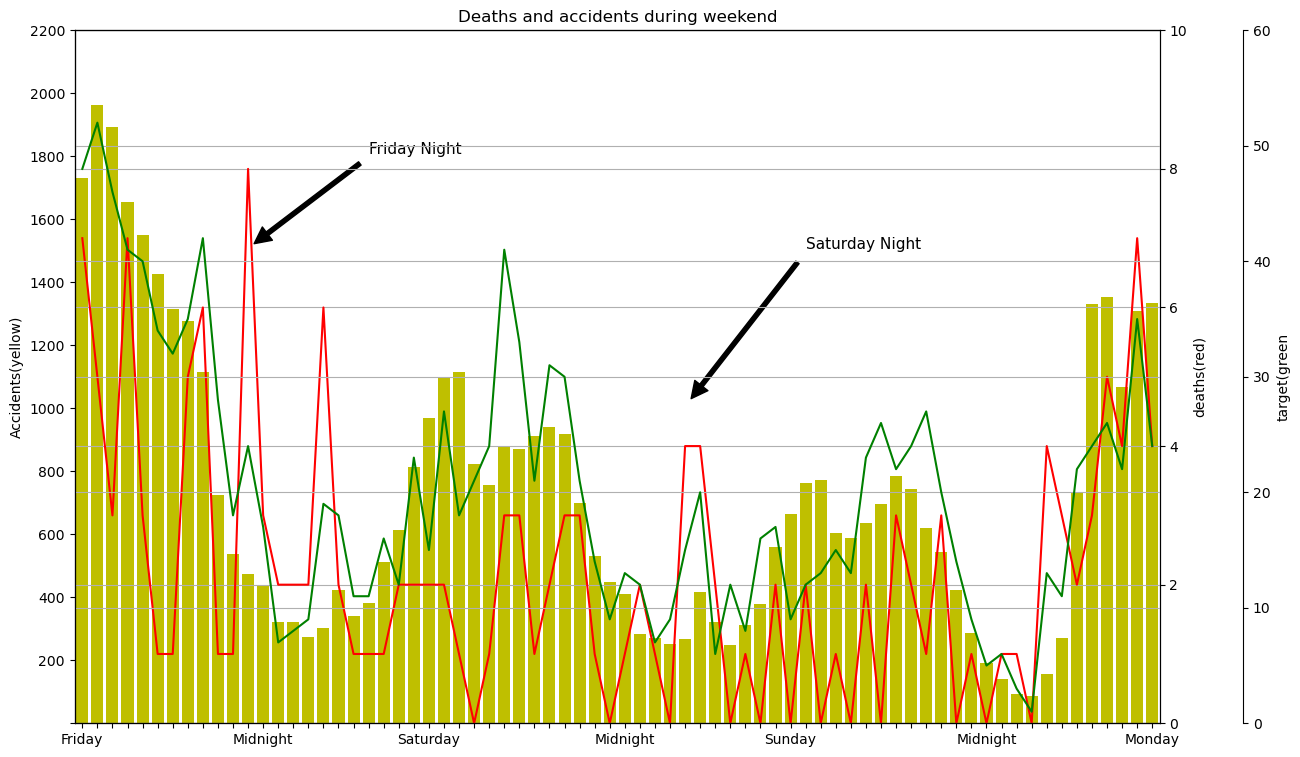

In [12]:
weekend = accidents[accidents['weekday'].isin(['Fri', 'Sat', 'Sun', 'Mon'])][['num_incident', 'num_deaths', 'weekday', 'hour','num_victims','target']].groupby(['weekday', 'hour']).agg\
({'num_incident': 'count', 'num_deaths': 'sum','num_victims':'sum','target':'sum'})

weekend= weekend.reindex(['Fri', 'Sat', 'Sun', 'Mon'], level=0)

for hour in range(0,13):
    weekend.drop(index=('Fri', hour),inplace=True)
for hour in range(13,24):
    weekend.drop(index=('Mon', hour),inplace=True)
weekend.columns =['num_accidents', 'num_deaths','num_victims','target']
ratios = weekend[weekend.columns[-3:]].div(weekend.num_accidents,axis=0)*100
ratios.columns = ['ratio_' + col for col in ratios.columns]
weekend = pd.concat([weekend,ratios],axis=1)

squad = ['' for x in range(0,72)]
for i in [12,36,60]: 
    squad[i] = 'Midnight'
squad[0] = 'Friday'
squad[23] = 'Saturday'
squad[47] = 'Sunday'
squad[71] = 'Monday'

yticks = [str(x) if x!=0 else '' for x in range(0,1400,200)]

fig = plt.figure(figsize=(14, 9)) 
ax = fig.add_subplot(111) 
ax2 = ax.twinx() 
ax3 = ax.twinx()
 

width = 0.4
# weekend.plot(kind='bar', y='number_of_accidents', color='y', ax=ax, legend=False)
ax.bar(range(len(weekend)), weekend.num_accidents,color='y', label='accidents')
# weekend.plot(kind='line', y='number_of_deaths', color='r', ax=ax2, legend=False)
ax2.plot(range(len(weekend)),weekend.num_deaths, c ='r', label='deaths')
ax3.plot(range(len(weekend)), weekend.target,c='g',label='target')
ax.set_ylim(0,2200)
ax.yaxis.set_major_locator(ticker.MultipleLocator(200))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: '' if x==0 else f'{int(x)}'))
ax.set_ylabel('Accidents(yellow)')
ax2.set_ylim(0,10)
ax2.set_ylabel('deaths(red)')
ax.grid(False)
ax3.set_ylim(0,60)
ax3.set_ylabel('target(green')
ax3.spines['right'].set_position(('outward', 60))
ax.set_xticks(range(len(squad)))
ax.set_xticklabels(squad, rotation=0)
ax.set_xlim(-0.5,71.5)

fn_peak_x = weekend['num_deaths'].iloc[:24].argmax()
sn_peak_x = weekend['num_deaths'].iloc[24:48].argmax()
ax.annotate('Friday Night', xy=(fn_peak_x, weekend['num_deaths'].iloc[fn_peak_x]+1500), xytext=(fn_peak_x +8, weekend['num_deaths'].iloc[fn_peak_x]+1800), 
             arrowprops=dict(facecolor='black', shrink=0.05, width=3),
           fontsize=11)
ax.annotate('Saturday Night', xy=(sn_peak_x + 24,weekend['num_deaths'].iloc[sn_peak_x]+1000 ), xytext=(sn_peak_x+32, weekend['num_deaths'].iloc[sn_peak_x]+1500), 
             arrowprops=dict(facecolor='black', shrink=0.05, width=3),
           fontsize = 11)

plt.title('Deaths and accidents during weekend')
plt.show()


> Interesting to highlight something we all knew: being that deaths ioncrease during Friday night and Saturday night, bringing the target up.

## 5.2 **Weekend Analysis**.Ratios


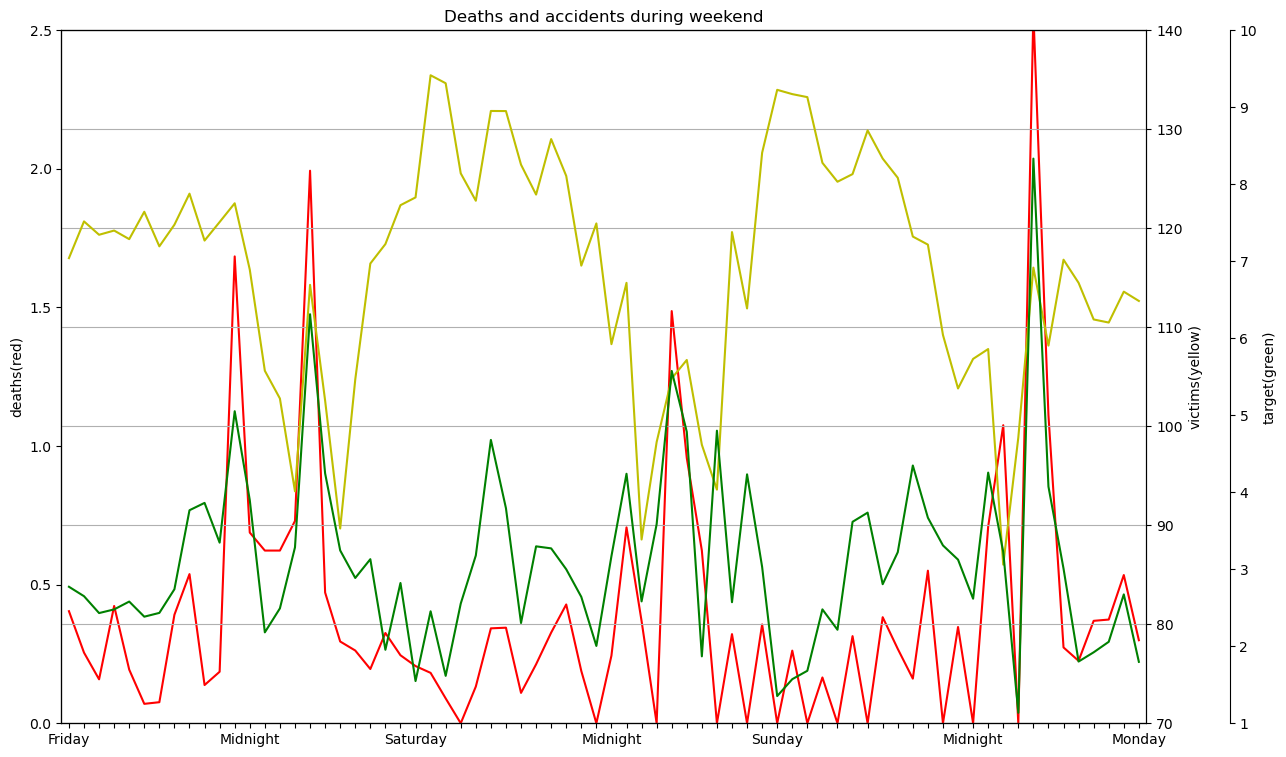

In [10]:
#weekend[weekend.columns[-3:]].plot()
fig = plt.figure(figsize=(14, 9)) 
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax3 = ax.twinx()
ax.plot(range(len(weekend)),weekend[weekend.columns[-3]], c ='r', label='deaths')
ax2.plot(range(len(weekend)),weekend[weekend.columns[-2]], color ='y', label='victims')
ax3.plot(range(len(weekend)),weekend[weekend.columns[-1]], color ='g', label='target')
ax.set_xticks(range(len(squad)))
ax.set_xticklabels(squad, rotation=0)
ax.set_ylim(0,2.5)
ax.grid(False)
ax.set_ylabel('deaths(red)')
ax2.set_ylim(70,140)
ax2.set_ylabel('victims(yellow)')
ax3.set_ylim(1,10)
ax3.set_ylabel('target(green)')
ax3.spines['right'].set_position(('outward', 60))
ax.set_xlim(-0.5,71.5)
plt.title('Deaths and accidents during weekend')
plt.grid(False)
plt.show();

In [11]:
weekend.corr()[(weekend.corr()>0.5)&(weekend.corr()<1)]


,num_accidents,num_deaths,num_victims,target,ratio_num_deaths,ratio_num_victims,ratio_target
num_accidents,NaN,NaN,0.994243,0.868692,NaN,NaN,NaN
num_deaths,NaN,NaN,NaN,0.582030,0.549923,NaN,NaN
num_victims,0.994243,NaN,NaN,0.869417,NaN,0.552301,NaN
target,0.868692,0.582030,0.869417,NaN,NaN,NaN,NaN
ratio_num_deaths,NaN,0.549923,NaN,NaN,NaN,NaN,0.711317
ratio_num_victims,NaN,NaN,0.552301,NaN,NaN,NaN,NaN
ratio_target,NaN,NaN,NaN,NaN,0.711317,NaN,NaN


> Ratios have their one lecture: It is interesting to see how much deaths and target are correlated when we focuse in the weekend only.
> Also, worths pointing ouyt how all the ratios peak at the same time during night time.

# Summary:
### *Accidents, Deaths, victims and target*.
1. Yearly Trajectory (Long-Term Macro Trends)

> Observation: The data reveals a general historical reduction in total accidents, injuries, and deaths over the 15-year span.

> Anomalies: A sharp, significant dip occurs in 2020 (corresponding with global pandemic mobility restrictions). While volumes have steadily recovered in the years since, they remain substantially lower than pre-2020 baselines

2. Monthly Seasonality & The Risk Paradox.
   
> Observation: The months of April and August stand out as the primary high-severity intervals.

> Insight: While August experiences a massive drop in absolute traffic volumes due to summer holidays , it records some of the highest per-accident mortality ratios and target variable rates. This indicates that although accidents are less frequent in August, they are statistically more severe when they do occur (often due to higher transit speeds on emptier city streets and dui).

3. Weekly Patterns (Weekday Volume vs. Weekend Risk)

> Observation: Friday is the peak day for absolute accident volumes, acting as the transition bridge between professional commuting and leisure travel.

> Insight: Conversely, Saturday dominates in terms of per-accident impact ratios and the target severity rate. This represents a distinct behavioral cohort shift: weekdays drive high-volume but minor bumper-to-bumper congestion accidents, whereas weekends see fewer but much more dangerous collisions.

4. Hourly Profiles (Daily Activity vs. Midnight Vulnerability)

> Observation: High-volume traffic hours (the morning and evening rush-hour windows) host the highest absolute number of incidents.

> Insight: However, the severe impact ratios and the target rate inversely peak during late-night and early-morning windows (specifically between 02:00 AM and 05:00 AM). Despite low traffic density, reduced visibility, driver fatigue, and potential impairment cause an escalation in severe injuries and fatalities per incident during these hours.

5. Weekend Analysis Validation

> Observation: Isolate-testing the weekend data perfectly consolidates and validates the localized trends noted above.

> Insight: The weekend cohort study confirms that a drop in vehicle exposure risk (lower absolute volume) directly correlates with an inflation of extreme safety failures (higher target mean and average deaths per accident). This emphasizes that human behavior and road conditions outside of working hours carry a fundamentally different and more critical safety profile.